# Breast Cancer Detection using XGBoost

###Jade Webb

###Mar 2026

###References:
###Optuna: https://www.kaggle.com/code/cahyaalkahfi/xgboost-model-tuning-using-optuna
###Pruning and Early Stopping: https://python.plainenglish.io/all-in-one-optuna-guide-smarter-hyperparameter-optimisation-for-your-ml-models-419f4f20e72a
###Dataset: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

## Installations and Imports

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.4 MB/s eta 0:00:00


In [ ]:
pip install optuna.integration

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 1.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import optuna
import optuna.visualization as vis
from optuna.integration import XGBoostPruningCallback
from optuna.samplers import TPESampler
from imblearn.combine import SMOTEENN
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
RANDOM_STATE = 42

##Load and Inspect Breast Cancer Dataset

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/XGBoost/breast-cancer.csv'

In [ ]:
df = pd.read_csv(file_path)

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
X = df.drop({"id", "diagnosis"}, axis=1)

In [ ]:
#map malignant to 1 and benign to 0
y = df["diagnosis"].replace({"M": 1, "B": 0})

/tmp/ipykernel_164/2820681248.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df["diagnosis"].replace({"M": 1, "B": 0})


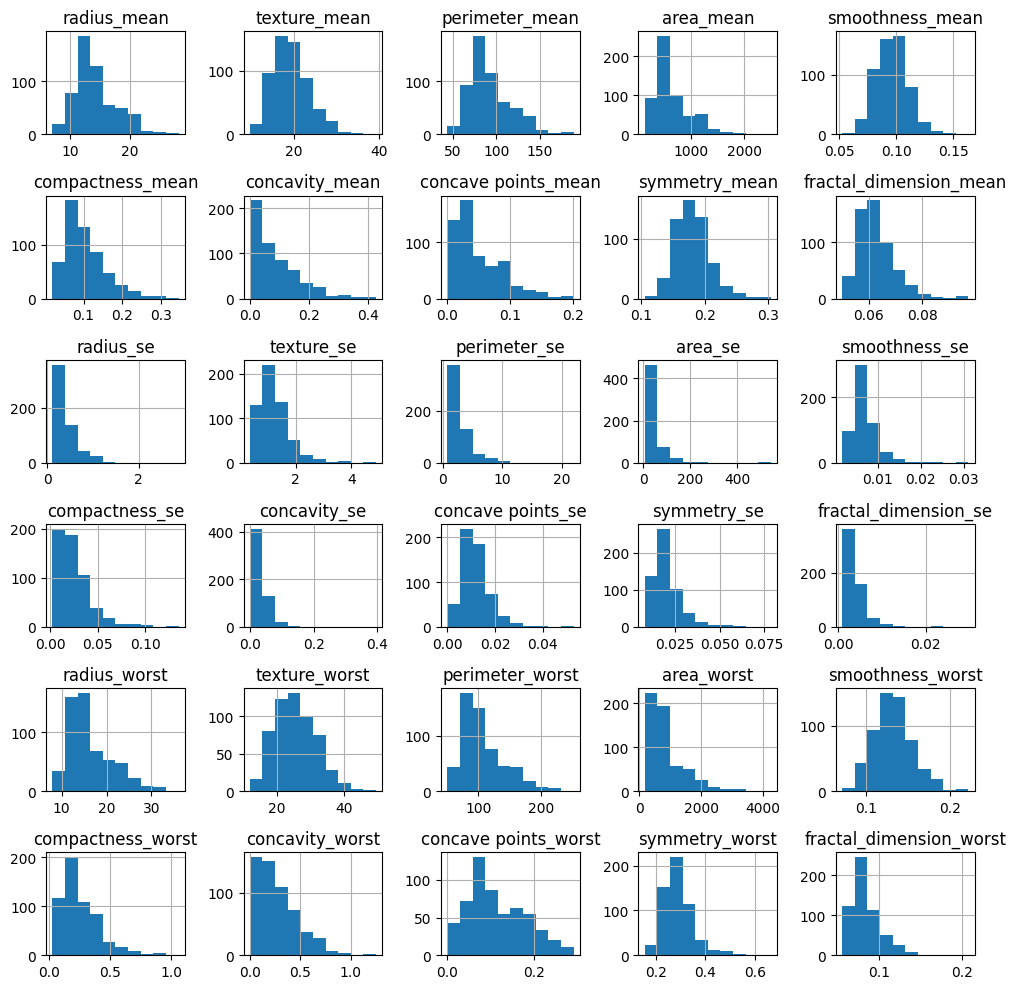

In [ ]:
#visualize features
X.hist(figsize=(10, 10))
plt.tight_layout()
plt.show()

In [ ]:
y.value_counts()

,count
diagnosis,
0,357
1,212


In [ ]:
#use over-sampling (SMOTE) and under-sampling (ENN) to decrease the gap between class counts
print(f"Original Class Counts:  Benign: {y.value_counts().loc[0]}, Malignant: {y.value_counts().loc[1]}")

sm = SMOTEENN(random_state=RANDOM_STATE)
X, y = sm.fit_resample(X, y)

print(f"Modified Class Counts:  Benign: {y.value_counts().loc[0]}, Malignant: {y.value_counts().loc[1]}")

Original Class Counts:  Benign: 357, Malignant: 212
Modified Class Counts:  Benign: 314, Malignant: 307


##Hold Out

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp)

In [ ]:
#validation set and metric
eval_set = [(X_val, y_val)]
eval_metric = 'logloss'

##XGBoost Model Tuning

###Optuna Study

In [ ]:
#optuna objective function
def objective(trial):

  params = {
      'eta': trial.suggest_float('eta', 1e-8, 1.0, log=True),
      'gamma': trial.suggest_float('gamma', 1e-8, 100, log=True),
      'max_depth': trial.suggest_int('max_depth', 3, 10),
      'min_child_weight': trial.suggest_int('min_child_weight', 1, 100),
      'subsample': trial.suggest_float('subsample', 0.1, 1.0),
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 1.0),
      'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
  }

  model = xgb.XGBClassifier(**params,
                            objective='binary:logistic',
                            eval_metric=eval_metric,
                            seed=RANDOM_STATE,
                            device='cuda',
                            callbacks=[
                               optuna.integration.XGBoostPruningCallback(trial, 'validation_0-logloss'),
                               xgb.callback.EarlyStopping(rounds=10, min_delta=1e-3, metric_name='logloss', save_best=True)
                            ],
                           )

  model.fit(X_train, y_train,
          eval_set=eval_set,
          verbose=True)

  print(f"Best Iteration: {model.best_iteration}")

  return model.best_score

In [ ]:
#optuna study
study = optuna.create_study(study_name="xgboost_study", direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=100, show_progress_bar=True, n_jobs=-1)

[I 2026-03-10 05:34:45,252] A new study created in memory with name: xgboost_study


  0%|          | 0/100 [00:00<?, ?it/s]

[0]	validation_0-logloss:0.69303
[0]	validation_0-logloss:0.69303
[1]	validation_0-logloss:0.69303
[2]	validation_0-logloss:0.69303
[1]	validation_0-logloss:0.69303
[2]	validation_0-logloss:0.69303
[3]	validation_0-logloss:0.69303
[4]	validation_0-logloss:0.69303
[3]	validation_0-logloss:0.69303
[4]	validation_0-logloss:0.69303[5]	validation_0-logloss:0.69303

[6]	validation_0-logloss:0.69303
[5]	validation_0-logloss:0.69303
[6]	validation_0-logloss:0.69303
[7]	validation_0-logloss:0.69303
[7]	validation_0-logloss:0.69303
[8]	validation_0-logloss:0.69303
[9]	validation_0-logloss:0.69303
[8]	validation_0-logloss:0.69303
[9]	validation_0-logloss:0.69303
Best Iteration: 0Best Iteration: 0
[I 2026-03-10 05:34:45,593] Trial 0 finished with value: 0.693031751821118 and parameters: {'eta': 0.005444096102688702, 'gamma': 0.0021042198887126027, 'max_depth': 9, 'min_child_weight': 79, 'subsample': 0.9880495987704058, 'colsample_bytree': 0.6815271114274914, 'n_estimators': 963}. Best is trial 0 w

In [ ]:
#best XGBoost parameters
best_params = study.best_params
print(f"\nBest parameters: {best_params}")


Best parameters: {'eta': 0.3592172945535058, 'gamma': 2.7156078635136536e-06, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.7880707622094965, 'colsample_bytree': 0.22224444259869333, 'n_estimators': 589}


In [ ]:
#optuna visualizations
display(vis.plot_param_importances(study))
display(vis.plot_optimization_history(study))

###Train Best Model

In [ ]:
#merge train and validation sets
X_trainval = pd.concat([X_train, X_val], ignore_index=True)
y_trainval = pd.concat([y_train, y_val], ignore_index=True)

In [ ]:
best_model = xgb.XGBClassifier(**best_params)
best_model.fit(X_trainval, y_trainval)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.22224444259869333, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eta=0.3592172945535058, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=2.7156078635136536e-06,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=589, n_jobs=None, ...)

##XGBoost Model Evaluation

In [ ]:
#train set
y_trainval_pred = best_model.predict(X_trainval)

trainval_accuracy = accuracy_score(y_trainval, y_trainval_pred)
print(f"Train Accuracy: {trainval_accuracy}")

trainval_f1_score = f1_score(y_trainval, y_trainval_pred)
print(f"Train F1 Score: {trainval_f1_score}")

trainval_cr = classification_report(y_trainval, y_trainval_pred)
print(f"\nTrain Report:\n{trainval_cr}")

Train Accuracy: 1.0
Train F1 Score: 1.0

Train Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       251
           1       1.00      1.00      1.00       245

    accuracy                           1.00       496
   macro avg       1.00      1.00      1.00       496
weighted avg       1.00      1.00      1.00       496



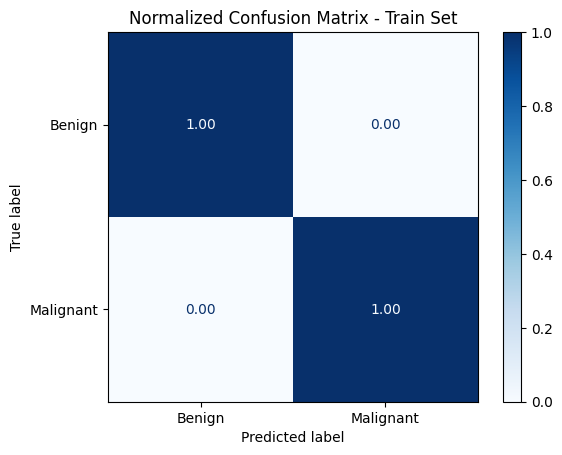

In [ ]:
#normalized confusion matrix - train set
cm_normalized_trainval = confusion_matrix(y_trainval, y_trainval_pred, normalize='true')
disp_norm_trainval = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_trainval, display_labels=["Benign", "Malignant"])
disp_norm_trainval.plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title("Normalized Confusion Matrix - Train Set")
plt.show()

In [ ]:
#test set
y_test_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy}")

test_f1_score = f1_score(y_test, y_test_pred)
print(f"Test F1 Score: {test_f1_score}")

test_cr = classification_report(y_test, y_test_pred)
print(f"\nTest Report:\n{test_cr}")

Test Accuracy: 1.0
Test F1 Score: 1.0

Test Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00        62

    accuracy                           1.00       125
   macro avg       1.00      1.00      1.00       125
weighted avg       1.00      1.00      1.00       125



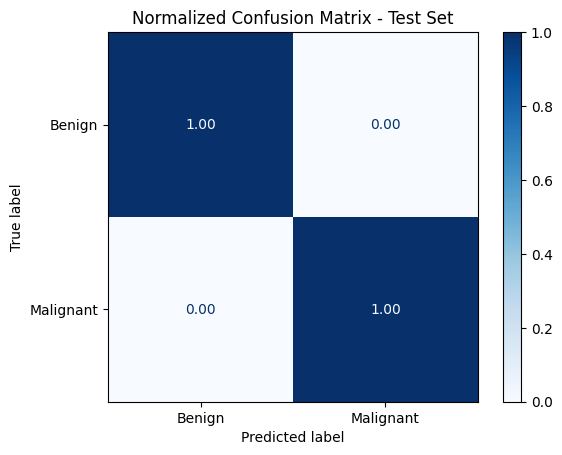

In [ ]:
#normalized confusion matrix - test set
cm_normalized_test = confusion_matrix(y_test, y_test_pred, normalize='true')
disp_norm_test = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_test, display_labels=["Benign", "Malignant"])
disp_norm_test.plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title("Normalized Confusion Matrix - Test Set")
plt.show()